In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as Ts

In [ ]:
data = pd.read_csv('sample_data/california_housing_train.csv')
print("Data Size : ",data.shape)

corr = data.corr(numeric_only=True)
target_corr = corr["median_house_value"].sort_values(ascending=False)
target_corr

Data Size :  (17000, 9)


,median_house_value
median_house_value,1.000000
median_income,0.691871
total_rooms,0.130991
housing_median_age,0.106758
households,0.061031
total_bedrooms,0.045783
population,-0.027850
longitude,-0.044982
latitude,-0.144917


### Thats mean only 5 cols are important
### ['median_income', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms']

In [ ]:
x = data.drop(columns=["population", "longitude", "latitude","median_house_value"], axis=1)
print("Featcher size",x.shape)
y = data['median_house_value']
print("Target Shape :",y.shape)

Featcher size (17000, 5)
Target Shape : (17000,)


In [ ]:
xtr, xte, ytr, yte = Ts(x, y, test_size=0.2, random_state=42)

# Building model 🏋️‍♂️





In [ ]:
def PLr (xtrain,ytrain):
   # In form of m1.x1 + m2.x2 ....... mn.xn + C
  xtrain = np.insert(xtrain,0,1,axis=1)
  m_and_c = np.linalg.inv(np.dot(xtrain.T,xtrain)).dot(xtrain.T).dot(ytrain)
  return m_and_c[0],m_and_c[1:] # returming C and M values

# def Predict(xtest,M,C):
#   return np.dot(xtest,M) + C

def Predict(xtest, M, C):
    return np.dot(xtest, M) + C


## Train Model

In [ ]:
c,m = PLr(xtr,ytr)
print("C (intercept) : ",c)
[(f"M{i+1} is {m[i]}") for i in range(5)]

C (intercept) :  -56573.2251112087


['M1 is 1892.5131274230166',
 'M2 is -27.241734615251833',
 'M3 is 150.5956851435418',
 'M4 is 15.38536920540266',
 'M5 is 49546.09930520317']

In [ ]:
print(m.shape,c.shape)
print(xte.shape,yte.shape)

(5,) ()
(3400, 5) (3400,)


In [ ]:
ypre = Predict(xte,m,c)
print(ypre.shape)
print("Predicted values:", *[f"{v:.2f}" for v in ypre[:5]])
print("Actual values   :", *[f"{v:.2f}" for v in yte[:5]])

(3400,)
Predicted values: 159575.43 438999.32 120082.35 167565.82 139188.67
Actual values   : 142700.00 500001.00 61800.00 162800.00 90600.00


## Evaluation of model

In [ ]:
y_true = np.asarray(yte)
y_pred = np.asarray(ypre)

# Calculate metrics manually
mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)

# R² (coefficient of determination)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Print neatly
print("📊 NumPy Evaluation Metrics")
print("----------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


📊 NumPy Evaluation Metrics
----------------------------
MAE  : 56750.3711
RMSE : 76709.9407
R²   : 0.5729


In [ ]:
mape = np.mean(np.abs((yte - ypre) / yte)) * 100
accuracy = 100 - mape

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Approx. Accuracy: {accuracy:.2f}%")

Mean Absolute Percentage Error (MAPE): 34.01%
Approx. Accuracy: 65.99%


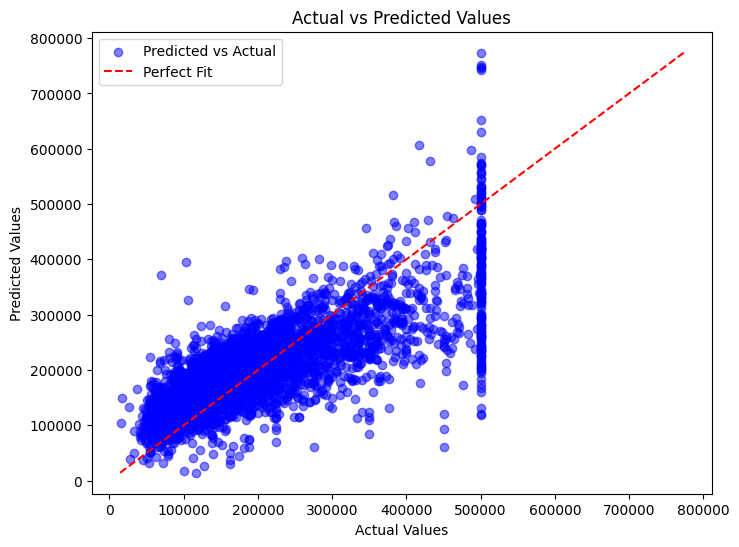

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure 1D arrays
y_true = np.asarray(yte)
y_pred = np.asarray(ypre)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')

# Perfect-fit line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')

# Labels
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(False)
plt.show()
